In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_iris, load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
def run_classification(dataset_loader, name):

    data = dataset_loader()
    X = data.data
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # entropy criterion behaves like ID3
    model = DecisionTreeClassifier(criterion="entropy", random_state=42)

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print("\n===== Classification Dataset:", name, "=====")

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average="weighted")
    recall = recall_score(y_test, predictions, average="weighted")
    f1 = f1_score(y_test, predictions, average="weighted")
    cm = confusion_matrix(y_test, predictions)

    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Confusion Matrix:\n", cm)

In [4]:
def run_regression():

    data = fetch_california_housing()
    X = data.data
    y = data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = DecisionTreeRegressor(random_state=42)

    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    print("\n===== Regression Dataset: California Housing =====")

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    print("MAE:", mae)
    print("MSE:", mse)
    print("RMSE:", rmse)
    print("R2 Score:", r2)

In [5]:
if __name__ == "__main__":

    # Multiple datasets for classification
    run_classification(load_iris, "Iris Dataset")
    run_classification(load_breast_cancer, "Breast Cancer Dataset")

    # Regression dataset
    run_regression()


===== Classification Dataset: Iris Dataset =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

===== Classification Dataset: Breast Cancer Dataset =====
Accuracy: 0.9473684210526315
Precision: 0.9488079172289698
Recall: 0.9473684210526315
F1 Score: 0.9468057045386604
Confusion Matrix:
 [[38  5]
 [ 1 70]]

===== Regression Dataset: California Housing =====
MAE: 0.45467918846899225
MSE: 0.495235205629094
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


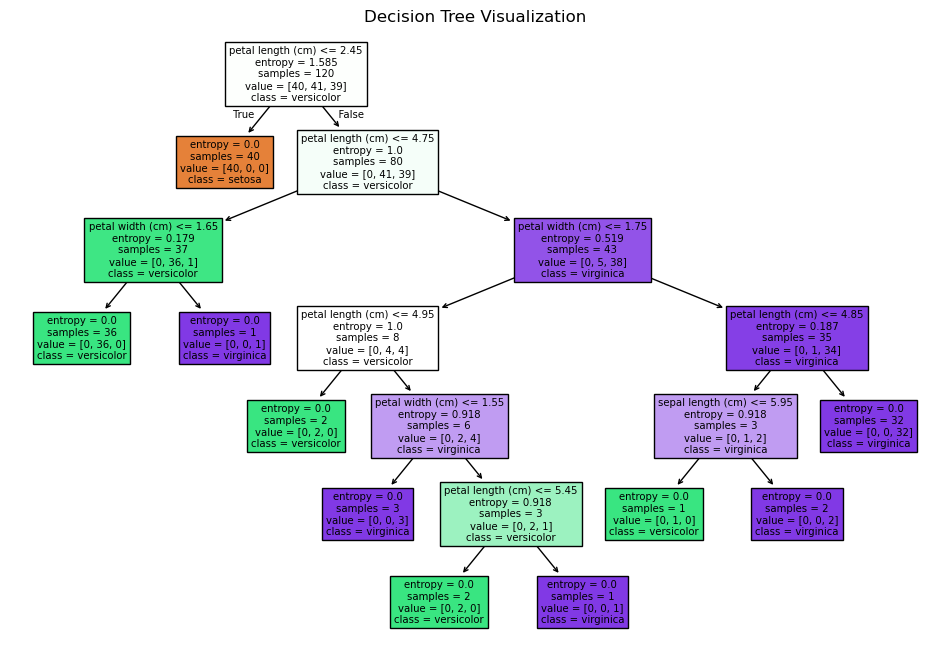

In [6]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Decision Tree (ID3 style using entropy)
model = DecisionTreeClassifier(criterion="entropy")
model.fit(X_train, y_train)

# Plot Decision Tree
plt.figure(figsize=(12,8))
plot_tree(
    model,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)

plt.title("Decision Tree Visualization")
plt.show()

MAE: 0.45467918846899225
MSE: 0.495235205629094
RMSE: 0.7037294974840077
R2 Score: 0.622075845135081


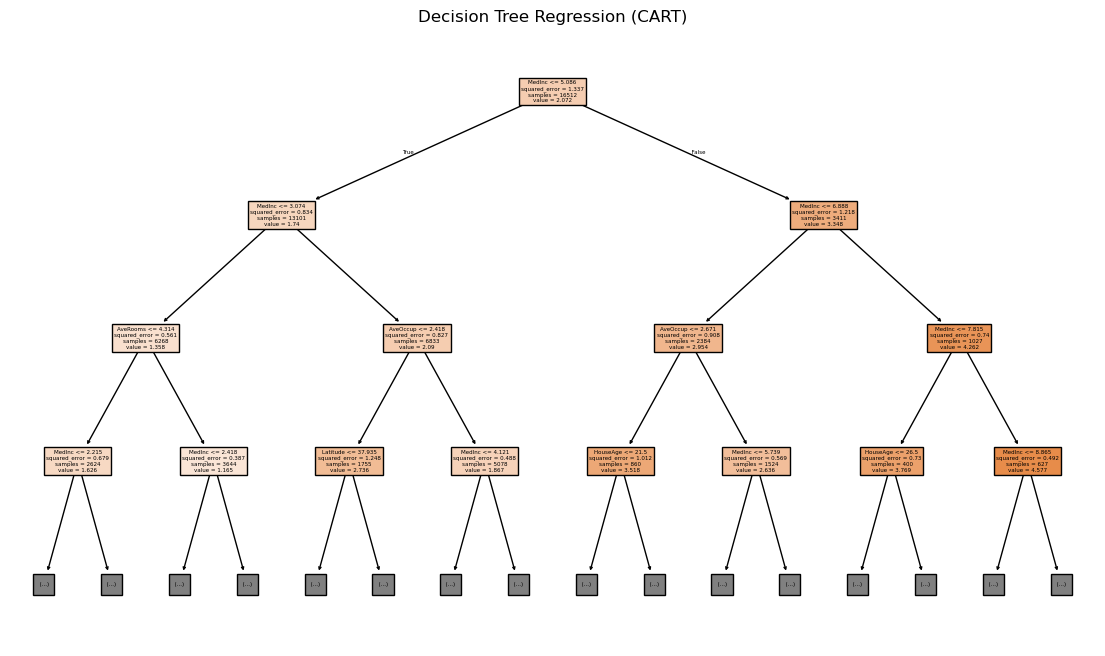

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CART model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

# Plot regression tree
plt.figure(figsize=(14,8))
plot_tree(model, feature_names=data.feature_names, filled=True, max_depth=3)
plt.title("Decision Tree Regression (CART)")
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
data = fetch_california_housing()
X = data.data
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train CART model with limited depth for small tree
model = DecisionTreeRegressor(random_state=42, max_depth=3)
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation metrics
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Plot small regression tree
plt.figure(figsize=(12,6))
plot_tree(model, feature_names=data.feature_names, filled=True, rounded=True)
plt.title("Small Regression Tree (max_depth=3)")
plt.show()